In [11]:
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
from collections import Counter

In [21]:
notebook_dir = os.getcwd()
in_the_wild_data_dir = os.path.join(notebook_dir, 'processed_imgs')
img_path = os.path.join(in_the_wild_data_dir, 'g', 'aug_0_g.c5d10b6f-5018-11f0-bd4e-4c034ff581fa.jpg')

img_ex = cv2.imread(img_path)

In [22]:
dataset_raw = tf.keras.utils.image_dataset_from_directory(
    in_the_wild_data_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=True,
    seed=123
)

data_iterator = dataset_raw.as_numpy_iterator()
data_iterator

Found 750 files belonging to 24 classes.


I0000 00:00:1750681996.093818    6013 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x7f5ffbd74880>)

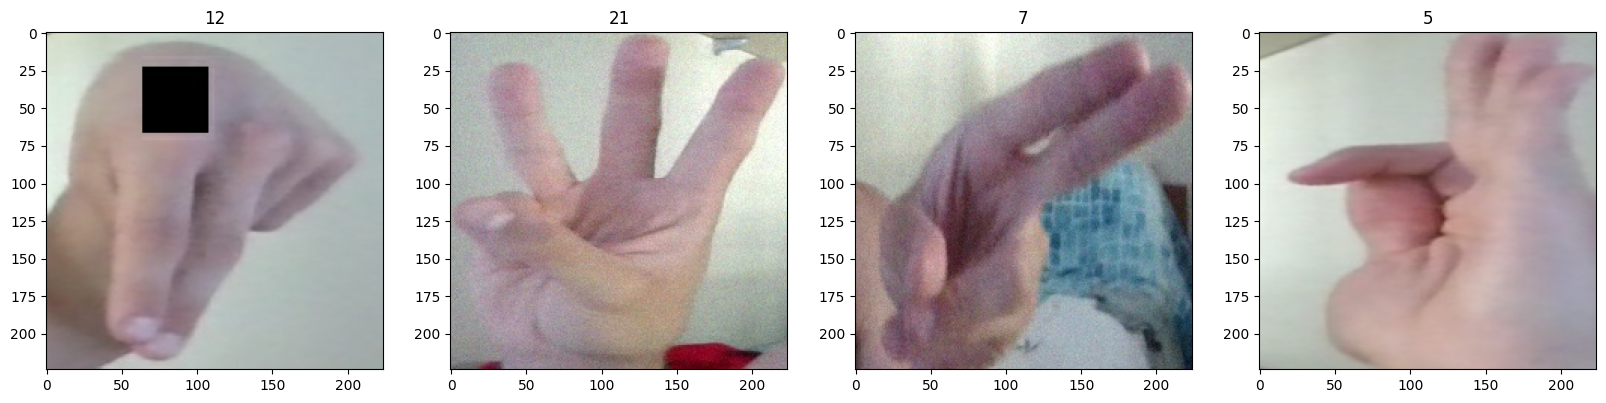

In [23]:
batch = data_iterator.next()

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

2025-06-23 14:33:25.917011: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


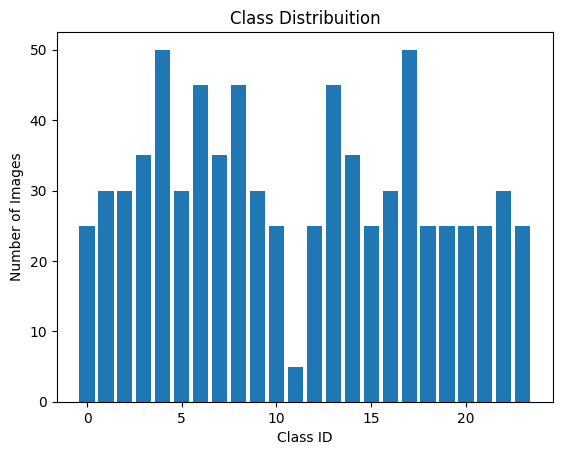

In [24]:
all_labels = []

for _, labels in dataset_raw:
    all_labels.extend(labels.numpy())

label_counts = Counter(all_labels)

# Plot labels distribuition
plt.bar(label_counts.keys(), label_counts.values())
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribuition")
plt.show()